### Linear Regression

Linear Regression is a most commonly used machine learning technique to predict a target value based upon the relationship between the target value and multiple (or single) independent predictor features.

To understand the concept, we take Boston Housing dataset available within scikit-learn module. The objective is to predict the price of houses based on the given features. Let us store the dataset into a dataframe and list its features and the target value.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

df = pd.read_csv("boston_housing.csv")

print(df.shape)
print(df.columns)
print(df.head())

(506, 14)
Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='str')
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


We observe top 5 samples of the dataset stored in dataframe df. Next, we assign the actual names of features to the dataframe columns.

In [3]:
# df.columns = boston.feature_names
print(df.head(5))
      


      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [6]:
# splitting the data into train and test sets

X = df.drop('MEDV', axis = 1)
              
## (use sklearn.model_selection in case sklearn.cross_validation results into error)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
        X, df.MEDV, test_size = 0.33, # Test data (33%)
        random_state = 42) # assign random_state to any value, to get same samples on each fresh run


In [8]:
# fitting the data into linear regression model
from sklearn.linear_model import LinearRegression

lm =   LinearRegression()
lm.fit(X_train, y_train)
pred_test = lm.predict(X_test)


Text(0, 0.5, 'Predicted Price')

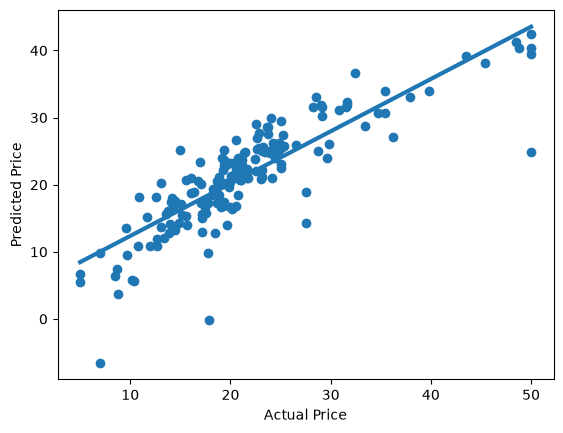

In [9]:
# we have the predicted values stored in pred_test , now we will visialize using the scatter plot

plt.scatter(y_test, pred_test)
plt.plot(np.unique(y_test), 
      np.poly1d(np.polyfit(y_test, pred_test, 1))(np.unique(y_test)),
      linewidth = 3)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

In [10]:
coeff_df = pd.DataFrame(X_train.columns, lm.coef_)
print(coeff_df)
mse = sklearn.metrics.mean_squared_error(y_test, pred_test)
print(mse)
      
                                          


                  0
-0.128750      CRIM
 0.037823        ZN
 0.058211     INDUS
 3.238668      CHAS
-16.169812      NOX
 3.902051        RM
-0.012851       AGE
-1.422224       DIS
 0.234854       RAD
-0.008213       TAX
-0.928722   PTRATIO
 0.011770         B
-0.547566     LSTAT
20.724023437339635
